# Figure 4

## Data provenance

The data loaded here (`records_with_amplification.pkl`) was generated on the ISTA SLURM cluster.
Each record corresponds to one matrix from the three non-normal ensembles (σ = 0.2, 0.5, 1.0).
For each matrix, the nonlinearity parameters were swept on a 40×40 grid:

```python
u_values = np.linspace(0, 4, 40)     # u = theta * g
u_values = np.linspace(0.25, 5, 40)  # r_max
```

At each grid point, `classify_behaviour` (see `utils.py`) was run for all N initial conditions.
A matrix is marked `rescued` at a grid point if it shows oscillations there. Proxy amplification was computed with `J_dynamics_numerical`.

The raw cluster output was ~3500 individual `.pkl` files (one per matrix), reassembled into
`records_with_amplification.pkl`. Each record is a dict with keys:
`task_id`, `ensemble`, `orig_idx`, `oscillated_at_default`, `u_values`, `c_values`,
`oscillation_map`, `ic_first`, `rescued`, `n_rescue_cells`, `amplification`.

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')
sys.path.append('../../results')

In [2]:
# --- Load data ---
# Download from Zenodo [DOI] and place under data/fig4/
with open('../../data/fig4/records_with_amplification.pkl', 'rb') as f:
    records = pickle.load(f)

df = pd.DataFrame(records)
df['rescue_fraction'] = df['oscillation_map'].apply(lambda m: np.asarray(m).mean())

n_rescued = df['rescued'].sum()
print(f'Loaded {len(records)} matrices. Rescued: {n_rescued} ({100*n_rescued/len(records):.1f}%)')
print(df.groupby('ensemble')['rescued'].agg(['count', 'sum', 'mean']))

Loaded 3398 matrices. Rescued: 3358 (98.8%)
          count   sum      mean
ensemble                       
0          1128  1128  1.000000
1          1170  1163  0.994017
2          1100  1067  0.970000


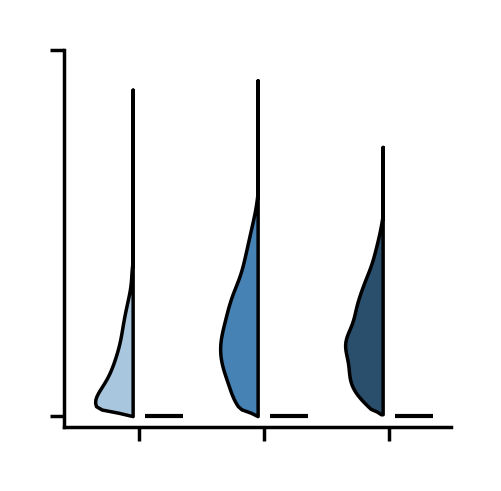

In [3]:
# --- MAIN: rescue fraction violin (broken axis, normal baseline = 0) ---
ensemble_order = [2, 1, 0]
data_non  = [df.loc[df['ensemble'] == k, 'rescue_fraction'].to_numpy() for k in ensemble_order]
positions = np.arange(1, len(data_non) + 1)
colors    = ['#a8c6de', '#4682B4', '#2a4f6c']
gap        = 0.05
fade_width = 0.02
halfwidth  = 0.35

fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
parts = ax.violinplot(data_non, positions=positions, widths=0.7,
                      showmeans=False, showmedians=False, showextrema=False)

for pos, (body, col) in enumerate(zip(parts['bodies'], colors), start=1):
    body.set_facecolor(col); body.set_edgecolor('black')
    body.set_alpha(1); body.set_linewidths(0.5)
    path  = body.get_paths()[0]
    verts = path.vertices
    verts[:, 0] = np.minimum(verts[:, 0], pos - gap)
    fade = np.clip(verts[:, 1] / fade_width, 0, 1)
    anchor = pos - gap
    left_mask = verts[:, 0] < anchor
    verts[left_mask, 0] = anchor - (anchor - verts[left_mask, 0]) * fade[left_mask]
    path.vertices = verts

for pos in positions:
    ax.hlines(y=0, xmin=pos + gap, xmax=pos + halfwidth, color='black', linewidth=0.6)

ax.set_ylim(-0.03, 1)
ax.set_yticks([0, 1]);    ax.set_yticklabels([])
ax.set_xticks(positions); ax.set_xticklabels([])
ax.set_xlim(0.4, 3.5)
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(0.5);  ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='y', width=0.5, length=2)
ax.tick_params(axis='x', width=0.5, length=2)
plt.show()

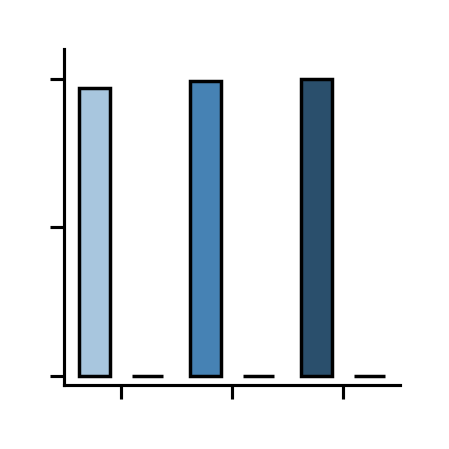

In [4]:
# --- MAIN: fraction of rescued matrices bar plot ---
eps = 0.0
frac_non_normal = np.array([
    np.mean(df.loc[df['ensemble'] == k, 'rescue_fraction'].to_numpy() > eps)
    for k in ensemble_order
])
frac_normal = np.zeros(len(ensemble_order))  # normal matrices not rescued by definition

x = np.arange(len(ensemble_order))
width, spacing = 0.28, 0.20

fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
bars1 = ax.bar(x - (width/2 + spacing/2), frac_non_normal, width,
               color='white', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + (width/2 + spacing/2), frac_normal,     width,
               color='black', edgecolor='black', linewidth=0.5)
for bar, col in zip(bars1, colors):
    bar.set_facecolor(col)

ax.set_xticks(x);           ax.set_xticklabels(['', '', ''])
ax.set_yticks([0, 0.5, 1]); ax.set_yticklabels(['', '', ''])
ax.set_ylim(-0.03, 1.1)
ax.spines['top'].set_visible(False);   ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.45); ax.spines['bottom'].set_linewidth(0.45)
ax.tick_params(length=2, width=0.45)
plt.tight_layout()
plt.show()

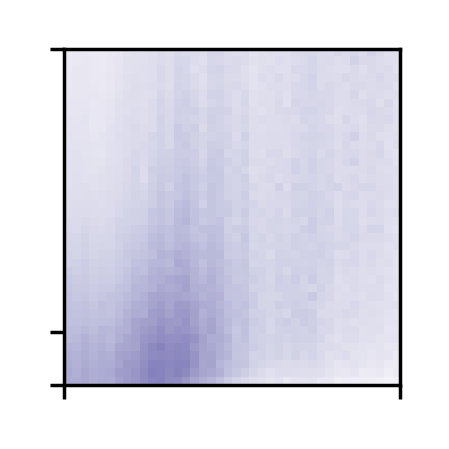

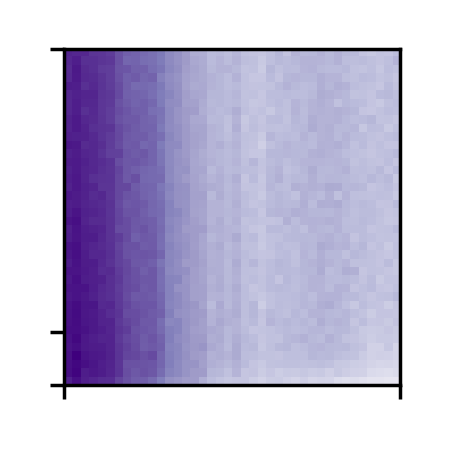

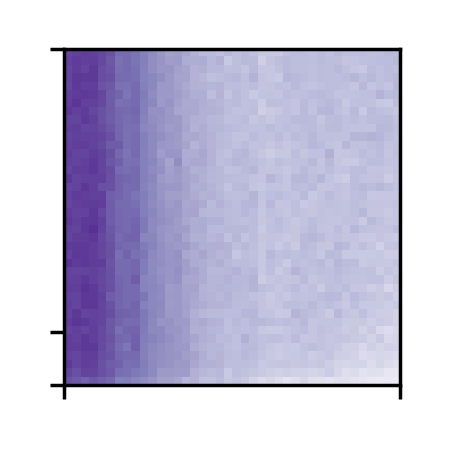

/var/folders/46/jrxtfx3d13v4tybb9f4_lz300000gn/T/ipykernel_65139/1741626749.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


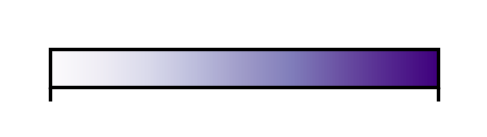

In [5]:
# --- SUPPLEMENTARY: oscillation count maps per ensemble ---
u_values = np.asarray(df.iloc[0]['u_values'])
c_values = np.asarray(df.iloc[0]['c_values'])

count_maps = {}
for k in ensemble_order:
    sub     = df[df['ensemble'] == k]
    stacked = np.stack([np.asarray(m) for m in sub['oscillation_map']])
    count_maps[k] = stacked.sum(axis=0).T  # shape (n_c, n_u)

vmax = max(cm.max() for cm in count_maps.values())
cmap = mpl.colormaps['Purples'].copy()
norm = mpl.colors.Normalize(vmin=0, vmax=vmax)

for k in ensemble_order:
    fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
    ax.imshow(count_maps[k], aspect='auto', origin='lower',
              cmap=cmap, norm=norm,
              extent=[u_values.min(), u_values.max(),
                      c_values.min(), c_values.max()],
              interpolation='nearest')
    ax.set_xticks([0, 4]);       ax.set_xticklabels([])
    ax.set_yticks([0.25, 1, 5]); ax.set_yticklabels([])
    for side in ('top', 'right', 'left', 'bottom'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.5)
    ax.tick_params(axis='y', width=0.5, length=2)
    ax.tick_params(axis='x', width=0.5, length=2)
    plt.tight_layout()
    plt.show()

# --- standalone colorbar ---
fig, ax = plt.subplots(figsize=(1.0, 0.1), dpi=500)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal')
cb.set_ticks([0, vmax]); cb.set_ticklabels([])
cb.outline.set_linewidth(0.5)
ax.tick_params(width=0.5, length=2)
plt.tight_layout()
plt.show()

In [6]:
# Files were generated by sweeping a and b on a 41x41 grid (a_values = b_values = linspace(0, 2, 41))
# for one exemplar matrix per ensemble. Each cell contains a list of N behaviour labels.
panel_names = ['sigma02', 'sigma05', 'sigma1']

behaviours_ab_clean = {}
for name in panel_names:
    behaviours_ab_clean[name] = np.load(
        f'../../data/fig4/behaviours_ab_final_{name}.npy', allow_pickle=True)

a_values       = np.linspace(0, 2.0, 41)
b_values       = np.linspace(0, 2.0, 41)
a_values_clean = a_values[1:]   # drop a=0 to match saved array shape (40, 41)


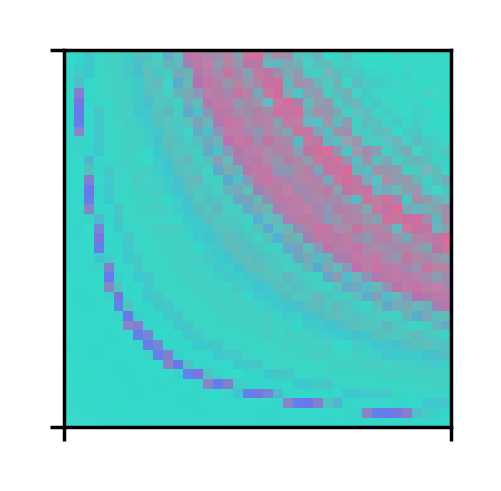

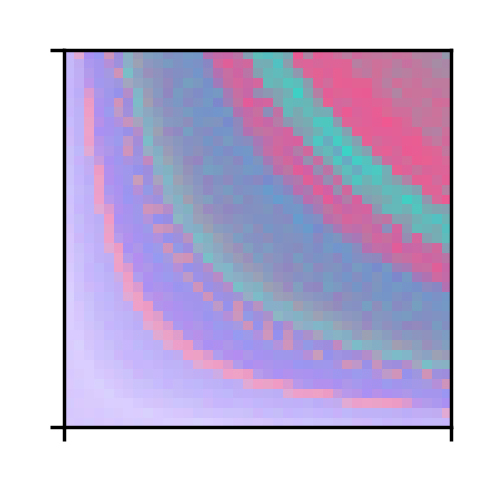

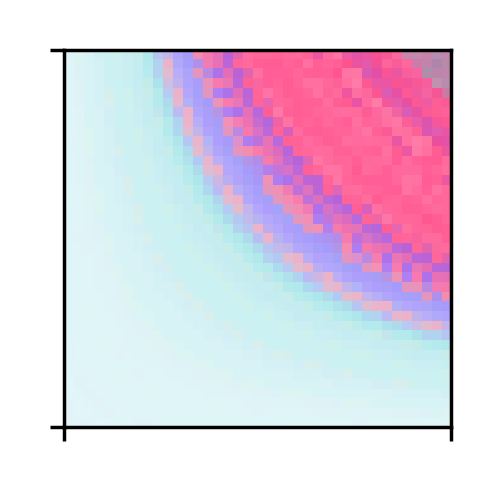

In [8]:
# --- MAIN: RGB heatmap (behaviour fraction colour-blended per cell) ---
from matplotlib.colors import to_rgb

OSC            = {'periodic', 'quasi-periodic'}
COLOR_PERIODIC = np.array(to_rgb('#7C4DFF'))
COLOR_STEADY   = np.array(to_rgb('#32DCC8'))
COLOR_CHAOS    = np.array(to_rgb('#FF508C'))
WHITE          = np.array([1.0, 1.0, 1.0])

def cell_to_rgb(labels):
    n   = len(labels)
    f_p = sum(1 for x in labels if x in OSC)       / n
    f_s = sum(1 for x in labels if x == 'new_fp')  / n
    f_c = sum(1 for x in labels if x == 'chaotic') / n
    f_b = sum(1 for x in labels if x == '0_fp')    / n
    total = f_b + f_p + f_s + f_c
    if total < 1e-12:
        return np.array([0.7, 0.7, 0.7])
    f_b, f_p, f_s, f_c = f_b/total, f_p/total, f_s/total, f_c/total
    f_active = f_p + f_s + f_c
    if f_active < 1e-12:
        active_color = WHITE
    else:
        active_color = (f_p * COLOR_PERIODIC + f_s * COLOR_STEADY
                        + f_c * COLOR_CHAOS) / f_active
    return f_b * WHITE + f_active * active_color

def behaviours_to_rgb(arr):
    n_a, n_b = arr.shape
    out = np.zeros((n_a, n_b, 3))
    for ia in range(n_a):
        for ib in range(n_b):
            out[ia, ib] = cell_to_rgb(arr[ia, ib])
    return out

panels = [
    ('sigma02',    'panel_sigma02'),
    ('sigma05',    'panel_sigma05'),
    ('sigma1',     'panel_sigma1'),
]

for name, fname in panels:
    rgb = behaviours_to_rgb(behaviours_ab_clean[name])
    fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
    ax.imshow(rgb.transpose(1, 0, 2), origin='lower',
              extent=[a_values_clean[0], a_values_clean[-1],
                      b_values[0], b_values[-1]],
              aspect='auto', interpolation='nearest')
    ax.set_xticks([0.1, 2]); ax.set_xticklabels(['', ''])
    ax.set_yticks([0.1, 2]); ax.set_yticklabels(['', ''])
    ax.set_xlim(0.1, 2); ax.set_ylim(0.1, 2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(length=2, width=0.5)
    plt.show()


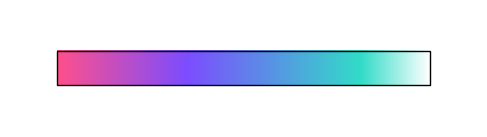

In [9]:
# --- MAIN: colour legend bar ---
import matplotlib.patches as mpatches

def lerp(c1, c2, n):
    t = np.linspace(0, 1, n)[:, None]
    return (1 - t) * c1 + t * c2

cycle = np.vstack([
    lerp(COLOR_CHAOS,    COLOR_PERIODIC, 150),
    lerp(COLOR_PERIODIC, COLOR_STEADY,   200),
    lerp(COLOR_STEADY,   WHITE,           80),
])

fig, ax = plt.subplots(figsize=(1.0, 0.1), dpi=500)
ax.imshow(cycle.reshape(1, -1, 3), extent=[0, 1, 0, 1], aspect='auto')
ax.add_patch(mpatches.Rectangle((0, 0), 1, 1, fill=False,
                                 edgecolor='k', linewidth=0.2))
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.05, 1.05)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
plt.show()


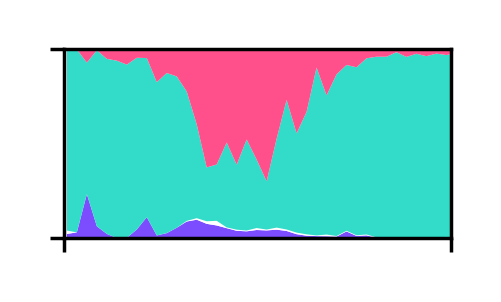

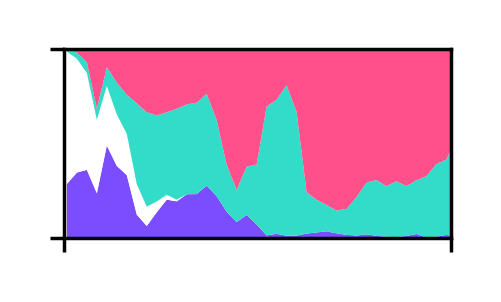

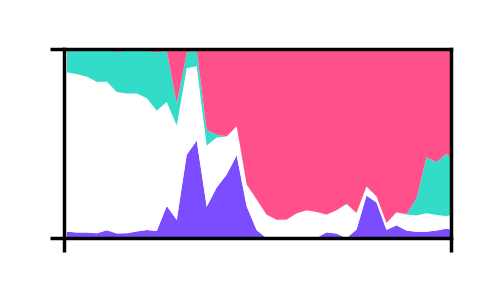

In [10]:
# --- MAIN: stacked area plot (behaviour fractions vs a*b) ---
STACK = [
    ('periodic', '#7C4DFF', lambda labels: sum(1 for x in labels if x in OSC)        / len(labels)),
    ('baseline', '#FFFFFF', lambda labels: sum(1 for x in labels if x == '0_fp')     / len(labels)),
    ('steady',   '#32DCC8', lambda labels: sum(1 for x in labels if x == 'new_fp')   / len(labels)),
    ('chaotic',  '#FF508C', lambda labels: sum(1 for x in labels if x == 'chaotic')  / len(labels)),
]

N_BINS  = 40
AB_MAX  = 4.0
edges   = np.linspace(0, AB_MAX, N_BINS + 1)
centers = (edges[:-1] + edges[1:]) / 2

for name, fname in panels:
    arr = behaviours_ab_clean[name]
    n_a, n_b = arr.shape
    sums   = {key: np.zeros(N_BINS) for key, _, _ in STACK}
    counts = np.zeros(N_BINS)
    for ia in range(n_a):
        for ib in range(n_b):
            ab = a_values_clean[ia] * b_values[ib]
            k  = max(0, min(N_BINS - 1, np.searchsorted(edges, ab) - 1))
            for key, _, fn in STACK:
                sums[key][k] += fn(arr[ia, ib])
            counts[k] += 1
    nz     = counts > 0
    series = {key: sums[key][nz] / counts[nz] for key, _, _ in STACK}
    x      = centers[nz]

    fig, ax = plt.subplots(figsize=(1, 0.5), dpi=500)
    ax.stackplot(x,
                 [series[k] for k, _, _ in STACK],
                 colors=[c for _, c, _ in STACK],
                 linewidth=0)
    ax.set_xticks([0.02, 3.9]); ax.set_xticklabels(['', ''])
    ax.set_yticks([0, 1]);      ax.set_yticklabels(['', ''])
    ax.set_xlim(0.02, AB_MAX - 0.1)
    ax.set_ylim(0, 1)
    for s in ax.spines.values():
        s.set_linewidth(0.5)
    ax.tick_params(length=2, width=0.5)
    plt.show()


## Supplementary: (u, r_max) sweep for one exemplar matrix per ensemble

The same behaviour classification was repeated for one representative matrix from each ensemble
over a 40×40 grid of nonlinearity parameters:

```python
u_values = np.linspace(0, 4, 40)      # u = theta * g
c_values = np.linspace(0.25, 5, 40)   # r_max
```

In [13]:
# --- Load (u, c) sweep data ---
# Download from Zenodo [DOI] and place under data/fig4/
uc_names = ['sigma02', 'sigma05', 'sigma1']

behaviours_uc = {}
for name in uc_names:
    behaviours_uc[name] = np.load(
        f'../../data/fig4/behaviours_uc_{name}.npy', allow_pickle=True)

u_values = np.linspace(0, 4, 40)
c_values = np.linspace(0.25, 5, 40)

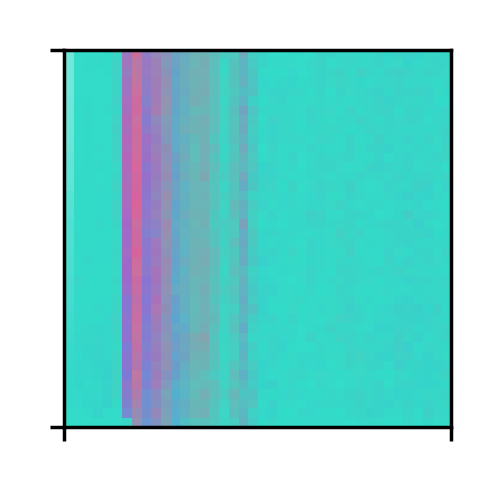

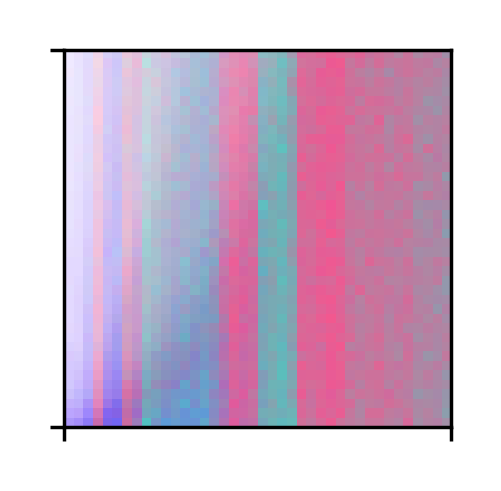

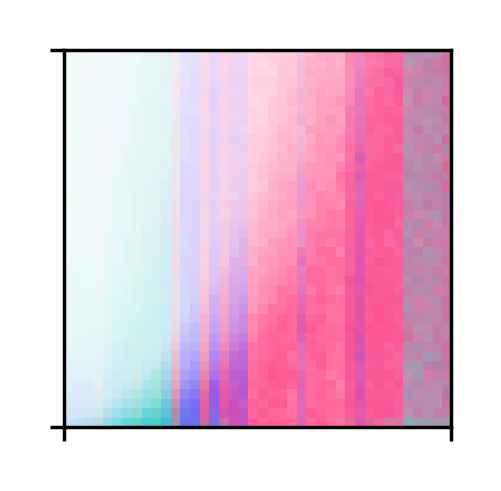

In [14]:
# --- RGB heatmap over (u, r_max) grid ---
# cell_to_rgb and behaviours_to_rgb are defined in cell-07 above

for name, arr in behaviours_uc.items():
    rgb = behaviours_to_rgb(arr)
    fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
    ax.imshow(rgb.transpose(1, 0, 2), origin='lower',
              extent=[u_values[0], u_values[-1],
                      c_values[0], c_values[-1]],
              aspect='auto', interpolation='nearest')
    ax.set_xticks([u_values[0], u_values[-1]]); ax.set_xticklabels(['', ''])
    ax.set_yticks([c_values[0], c_values[-1]]); ax.set_yticklabels(['', ''])
    ax.set_xlim(u_values[0], u_values[-1])
    ax.set_ylim(c_values[0], c_values[-1])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(length=2, width=0.5)
    plt.show()


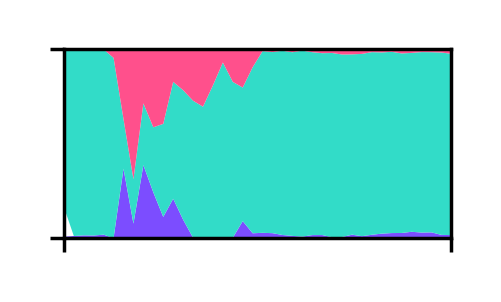

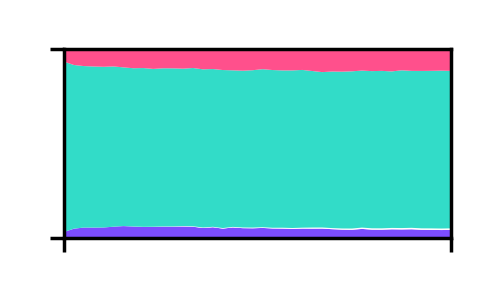

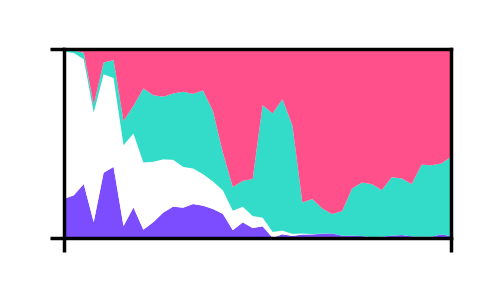

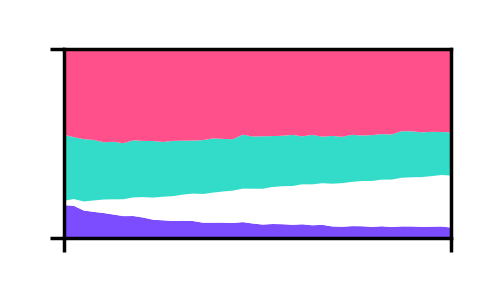

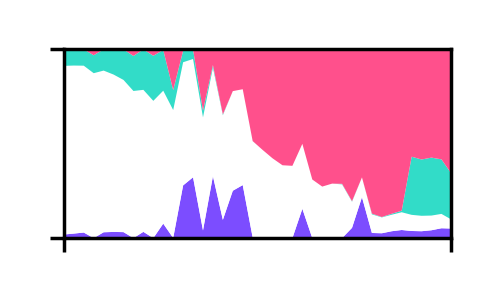

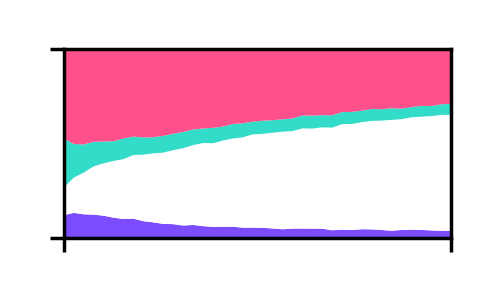

In [16]:
# --- Stacked area: marginals (averaged over the other axis) ---
def marginal_along_axis(arr_2d, sweep_axis):
    n_sweep = arr_2d.shape[sweep_axis]
    out = {key: np.zeros(n_sweep) for key, _, _ in STACK}
    for i in range(n_sweep):
        strip = arr_2d[i, :] if sweep_axis == 0 else arr_2d[:, i]
        for key, _, fn in STACK:
            out[key][i] = np.mean([fn(cell) for cell in strip])
    return out

for name in behaviours_uc:
    arr = behaviours_uc[name]
    plot_stack(u_values, marginal_along_axis(arr, sweep_axis=0),
               xlim=(u_values[0], u_values[-1]))
    plot_stack(c_values, marginal_along_axis(arr, sweep_axis=1),
               xlim=(c_values[0], c_values[-1]))
